In [1]:
import glob
import numpy as np
import xarray as xr
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from dask.diagnostics import ProgressBar
# from PIL import Image

ProgressBar().register()

In [2]:
for file_path in sorted(glob.glob('/glade/work/skygale/pbi-data/combined/*.nc')):
    print(file_path)

/glade/work/skygale/pbi-data/combined/AMSR2_12.5km_2012_2025.nc
/glade/work/skygale/pbi-data/combined/AMSR2_25km_2012_2025.nc
/glade/work/skygale/pbi-data/combined/G02202_25km_1978_2025.nc
/glade/work/skygale/pbi-data/combined/G10016_PROTO_25km_2025.nc
/glade/work/skygale/pbi-data/combined/NSIDC_0803_25km_2023_2025.nc


### 12.5km Scale

In [4]:
ds = xr.open_dataset('/glade/work/skygale/pbi-data/combined/AMSR2_12.5km_2012_2025.nc')
ds

<xarray.Dataset>
Dimensions:  (ni: 608, nj: 896, time: 4679)
Coordinates:
    lat      (ni, nj) float32 ...
    lon      (ni, nj) float32 ...
  * time     (time) datetime64[ns] 2012-07-02 2012-07-03 ... 2025-04-26
Dimensions without coordinates: ni, nj
Data variables:
    sic      (time, ni, nj) float64 ...

In [5]:
ds_sel = ds.sic.isel(time=159)
ds_sel

<xarray.DataArray 'sic' (ni: 608, nj: 896)>
[544768 values with dtype=float64]
Coordinates:
    lat      (ni, nj) float32 ...
    lon      (ni, nj) float32 ...
    time     datetime64[ns] 2012-12-08
Dimensions without coordinates: ni, nj

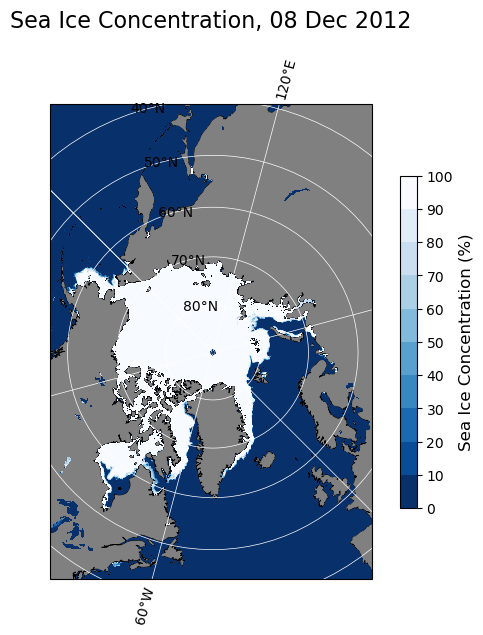

In [6]:
# Define projection and extent
crs = ccrs.Stereographic(central_latitude=90, central_longitude=-45)
extent = (-3850000, 3750000, -5350000, 5850000)

# Define norm
levels = np.arange(0, 105, 10)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6), subplot_kw={'projection': crs})
ax.set_extent(extent, crs=crs)

# Background: land, ocean, coastlines
ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')
ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=1, facecolor='gray', edgecolor='black', linewidth=0.5)

im = ax.pcolormesh(
    ds.lon,
    ds.lat,
    ds_sel,
    cmap='Blues_r',
    norm=norm,
    transform=ccrs.PlateCarree(),
)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='white')

# Colorbar with percentage formatting
cbar = plt.colorbar(im, orientation='vertical', boundaries=levels, ticks=np.linspace(0, 100, 11), pad=0.05, shrink=0.7)
cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

# Title in same style
date_str = ds_sel["time"].dt.strftime("%d %b %Y").item()
ax.set_title(f'Sea Ice Concentration, {date_str}', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

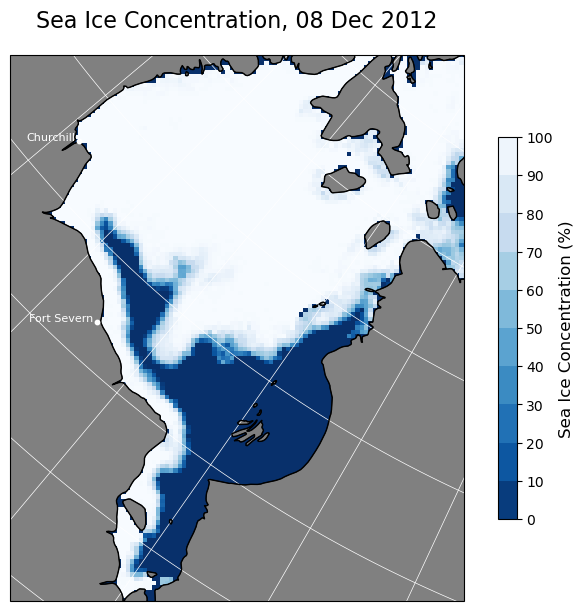

In [7]:
# Define projection
crs = ccrs.Stereographic(central_latitude=90, central_longitude=-45)

# Use exact NSIDC polar stereographic
crs_nsidc = ccrs.Stereographic(
    central_latitude=90,
    central_longitude=-45,
    true_scale_latitude=70,
    false_easting=0,
    false_northing=0
)

# Discrete levels
levels = np.arange(0, 105, 10)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True, subplot_kw={'projection': crs})

# 1. Add ocean background
ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')

# 2. Plot sea ice
im = ax.pcolormesh(
    ds.lon,
    ds.lat,
    ds_sel,
    cmap='Blues_r',
    transform=ccrs.PlateCarree(),
    zorder=1
)

# 3. Add land on top of sea ice
ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=2, facecolor='gray', edgecolor='black', linewidth=0.5)

# 4. Add coastlines for clarity
ax.coastlines(resolution='50m', zorder=3)

# Approximate extent around Hudson Bay in degrees
hudson_extent = [-85, -80, 51, 66]  # lon_min, lon_max, lat_min, lat_max
ax.set_extent(hudson_extent, crs=ccrs.PlateCarree())

# Gridlines
ax.gridlines(draw_labels=False, linewidth=0.5, color='white')

# Colorbar
cbar = plt.colorbar(im, orientation='vertical', boundaries=levels, ticks=np.linspace(0, 100, 11), pad=0.05, shrink=0.7)
cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

# Title
date_str = ds_sel["time"].dt.strftime("%d %b %Y").item()
ax.set_title(f'Sea Ice Concentration, {date_str}', fontsize=16, pad=20)

# ============================================================
# Load and set CRS
pop_places = gpd.read_file('ne_10m_populated_places.shp')
pop_places = pop_places.set_crs("EPSG:4326")

# Define Hudson Bay extent in lon/lat
lon_min, lon_max, lat_min, lat_max = -100, -70, 51, 60

# Filter cities that fall within the extent
pop_places_filtered = pop_places[
    (pop_places.geometry.x >= lon_min) &
    (pop_places.geometry.x <= lon_max) &
    (pop_places.geometry.y >= lat_min) &
    (pop_places.geometry.y <= lat_max)
]

# Now reproject to NSIDC stereographic
pop_places_proj = pop_places_filtered.to_crs(
    "+proj=stere +lat_0=90 +lat_ts=70 +lon_0=-45 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

# Filter for major cities
for _, row in pop_places_proj.iterrows():
    if row.get('SCALERANK', 10) < 4:

        # Plot city points
        ax.scatter(
            row.geometry.x,
            row.geometry.y,
            color='white',
            s=10,
            marker='o',
            transform=crs_nsidc,
            zorder=4,
        )

        # Plot city name
        ax.text(
            row.geometry.x-10000,
            row.geometry.y,
            row['NAME'],
            fontsize=8,
            color='white',
            transform=crs_nsidc,
            ha='right',
            zorder=5
            )
# ============================================================

plt.show()

### 25km Scale

In [8]:
ds = xr.open_dataset('/glade/work/skygale/pbi-data/combined/G02202_25km_1978_2025.nc')
print(ds.dims)
ds

Frozen({'time': 17121, 'y': 448, 'x': 304})


<xarray.Dataset>
Dimensions:                               (time: 17121, y: 448, x: 304)
Coordinates:
  * x                                     (x) float64 -3.838e+06 ... 3.738e+06
  * y                                     (y) float64 5.838e+06 ... -5.338e+06
  * time                                  (time) datetime64[ns] 1978-10-25 .....
Data variables:
    crs                                   (time) int32 ...
    cdr_seaice_conc_interp_spatial_flag   (time, y, x) uint8 ...
    cdr_seaice_conc_qa_flag               (time, y, x) uint8 ...
    cdr_seaice_conc_interp_temporal_flag  (time, y, x) uint8 ...
    cdr_seaice_conc                       (time, y, x) float64 ...
    cdr_seaice_conc_stdev                 (time, y, x) float32 ...
Attributes: (12/46)
    Conventions:               CF-1.11, ACDD-1.3
    date_created:              2024-11-11T23:59:35Z
    time_coverage_start:       1978-10-25T00:00:00Z
    time_coverage_end:         1978-10-25T23:59:59Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D
    ...                        ...
    geospatial_lat_min:        30.980564
    geospatial_lat_max:        90.0
    geospatial_lon_min:        -180.0
    geospatial_lon_max:        180.0
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east

In [9]:
ds_sel = ds.cdr_seaice_conc.isel(time=100)
ds_sel

<xarray.DataArray 'cdr_seaice_conc' (y: 448, x: 304)>
[136192 values with dtype=float64]
Coordinates:
  * x        (x) float64 -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y        (y) float64 5.838e+06 5.812e+06 5.788e+06 ... -5.312e+06 -5.338e+06
    time     datetime64[ns] 1979-02-02
Attributes:
    standard_name:          sea_ice_area_fraction
    coverage_content_type:  image
    units:                  1
    long_name:              NOAA/NSIDC CDR of Passive Microwave Sea Ice Conce...
    grid_mapping:           crs
    ancillary_variables:    cdr_seaice_conc_stdev cdr_seaice_conc_qa_flag
    valid_range:            [  0 100]

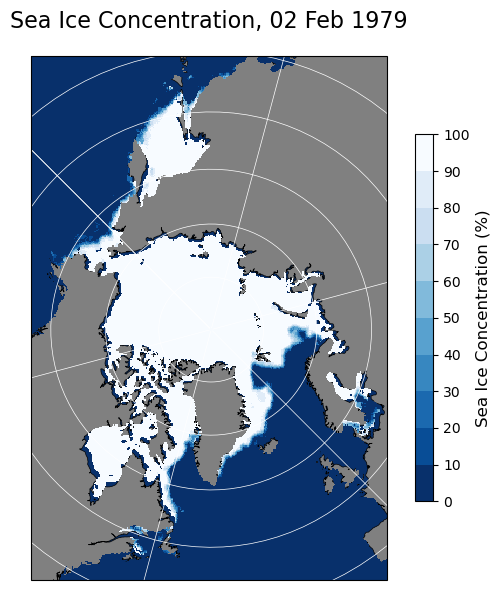

In [10]:
# Define projection and extent
crs = ccrs.Stereographic(central_latitude=90, central_longitude=-45)
# extent = (-3850000, 3750000, -5350000, 5850000)

# Define norm
levels = np.arange(0, 105, 10)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6), subplot_kw={'projection': crs})
# ax.set_extent(extent, crs=crs)

# Background: land, ocean, coastlines
ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')
ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=1, facecolor='gray', edgecolor='black', linewidth=0.5)

# Plot sea ice concentration as discrete colormap
im = ax.pcolormesh(
    ds.x.values,
    ds.y.values,
    ds_sel.values*100,
    cmap='Blues_r',
    norm=norm,
    transform=crs,
)

# Optional: gridlines
gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='white')

# Colorbar with percentage formatting
cbar = plt.colorbar(im, orientation='vertical', boundaries=levels, ticks=np.linspace(0, 100, 11), pad=0.05, shrink=0.7)
cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

# Title in same style
date_str = ds_sel["time"].dt.strftime("%d %b %Y").item()
ax.set_title(f'Sea Ice Concentration, {date_str}', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

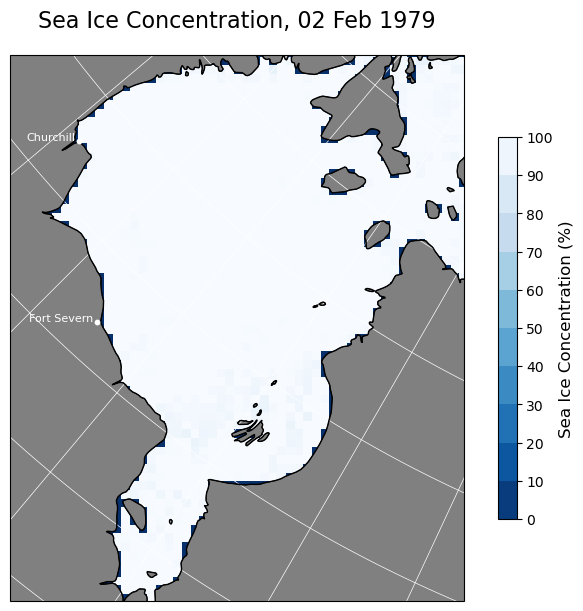

In [11]:
# Define projection
crs = ccrs.Stereographic(central_latitude=90, central_longitude=-45)

# Use exact NSIDC polar stereographic
crs_nsidc = ccrs.Stereographic(
    central_latitude=90,
    central_longitude=-45,
    true_scale_latitude=70,
    false_easting=0,
    false_northing=0
)

# Discrete levels
levels = np.arange(0, 105, 10)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True, subplot_kw={'projection': crs})

# 1. Add ocean background
ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')

# 2. Plot sea ice
im = ax.pcolormesh(
    ds.x.values,
    ds.y.values,
    ds_sel.values * 100,
    cmap='Blues_r',
    transform=crs_nsidc,
    zorder=1
)

# 3. Add land on top of sea ice
ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=2, facecolor='gray', edgecolor='black', linewidth=0.5)

# 4. Add coastlines for clarity
ax.coastlines(resolution='50m', zorder=3)

# Approximate extent around Hudson Bay in degrees
hudson_extent = [-85, -80, 51, 66]  # lon_min, lon_max, lat_min, lat_max
ax.set_extent(hudson_extent, crs=ccrs.PlateCarree())

# Gridlines
ax.gridlines(draw_labels=False, linewidth=0.5, color='white')

# Colorbar
cbar = plt.colorbar(im, orientation='vertical', boundaries=levels, ticks=np.linspace(0, 100, 11), pad=0.05, shrink=0.7)
cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

# Title
date_str = ds_sel["time"].dt.strftime("%d %b %Y").item()
ax.set_title(f'Sea Ice Concentration, {date_str}', fontsize=16, pad=20)

# ============================================================
# Load and set CRS
pop_places = gpd.read_file('ne_10m_populated_places.shp')
pop_places = pop_places.set_crs("EPSG:4326")

# Define Hudson Bay extent in lon/lat
lon_min, lon_max, lat_min, lat_max = -100, -70, 51, 60

# Filter cities that fall within the extent
pop_places_filtered = pop_places[
    (pop_places.geometry.x >= lon_min) & 
    (pop_places.geometry.x <= lon_max) &
    (pop_places.geometry.y >= lat_min) &
    (pop_places.geometry.y <= lat_max)
]

# Now reproject to NSIDC stereographic
pop_places_proj = pop_places_filtered.to_crs(
    "+proj=stere +lat_0=90 +lat_ts=70 +lon_0=-45 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

# Filter for major cities
for _, row in pop_places_proj.iterrows():
    if row.get('SCALERANK', 10) < 4: 

        # Plot city points
        ax.scatter(
            row.geometry.x,
            row.geometry.y,
            color='white',
            s=10,
            marker='o',
            transform=crs_nsidc,
            zorder=4,
        )

        # Plot city name
        ax.text(
            row.geometry.x-10000,
            row.geometry.y,
            row['NAME'],
            fontsize=8,
            color='white',
            transform=crs_nsidc,
            ha='right',
            zorder=5
            )
# ============================================================

plt.show()

### All Datasets

In [3]:
# List potential sea ice variable names
vars = ['am2_seaice_conc', 'cdr_seaice_conc', 'ICECON', 'sic']

# Allocate for dataset information
names, ds_all = [], []

for file_path in glob.glob('/glade/work/skygale/pbi-data/combined/*.nc'):
    name = file_path[38:-3]
    names.append(name)

    # Open dataset
    ds = xr.open_dataset(file_path)

    # Get sea ice
    for varname in vars:
        if varname in ds.data_vars:
            ds = ds[varname]
            break

    # Standardize DataArrays
    rename_dict = {}
    if 'ni' in ds.dims:
        rename_dict['ni'] = 'x'
    if 'nj' in ds.dims:
        rename_dict['nj'] = 'y'
    ds = ds.rename(rename_dict)

    # Reorder dimensions
    existing_dims = [dim for dim in ['time', 'y', 'x'] if dim in ds.dims]
    ds = ds.transpose(*existing_dims)

    print(ds.dims)
    ds_all.append(ds)

('time', 'y', 'x')
('time', 'y', 'x')
('time', 'y', 'x')
('time', 'y', 'x')
('time', 'y', 'x')


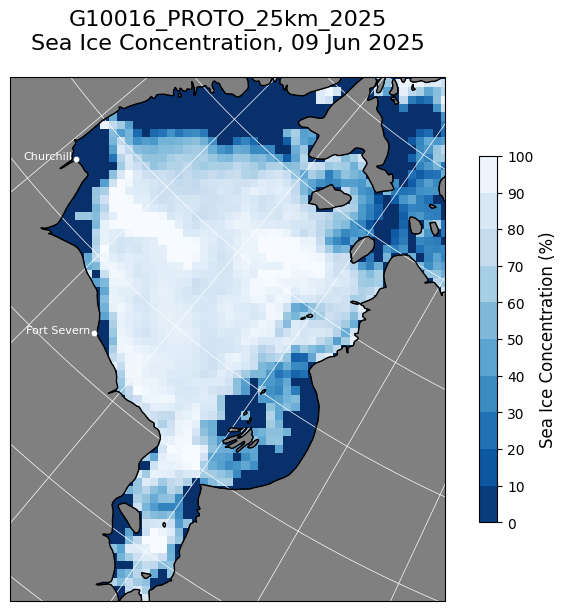

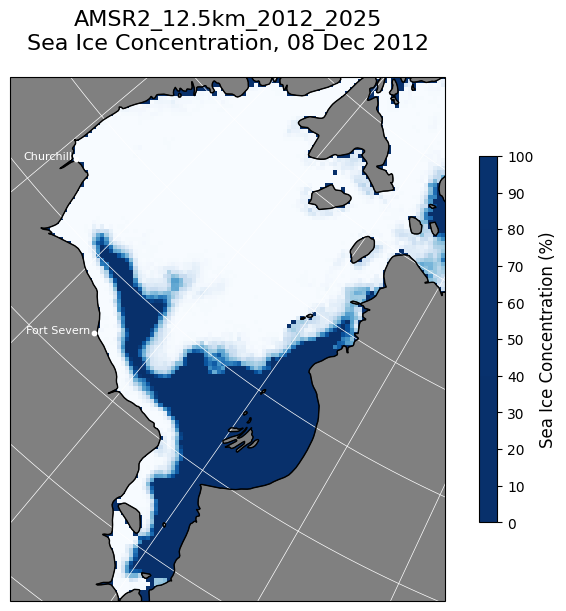

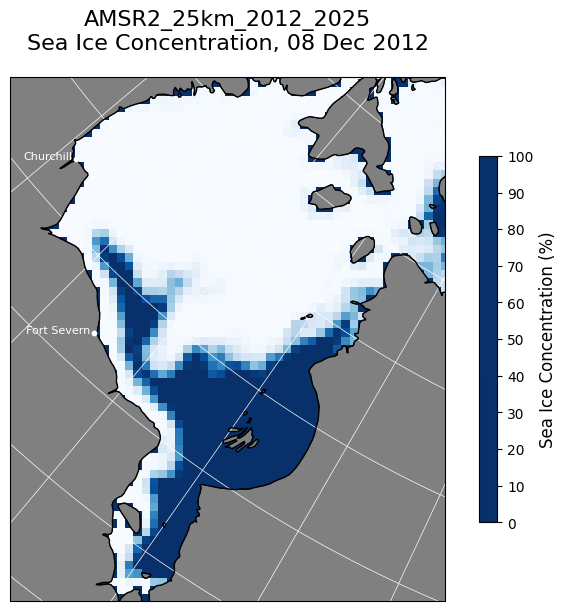

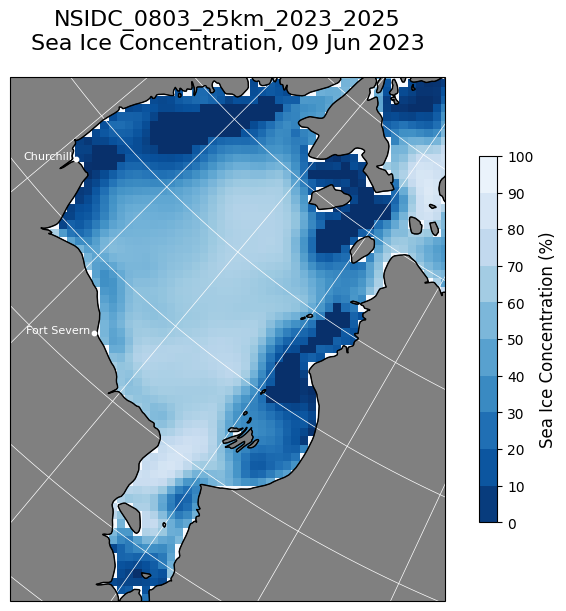

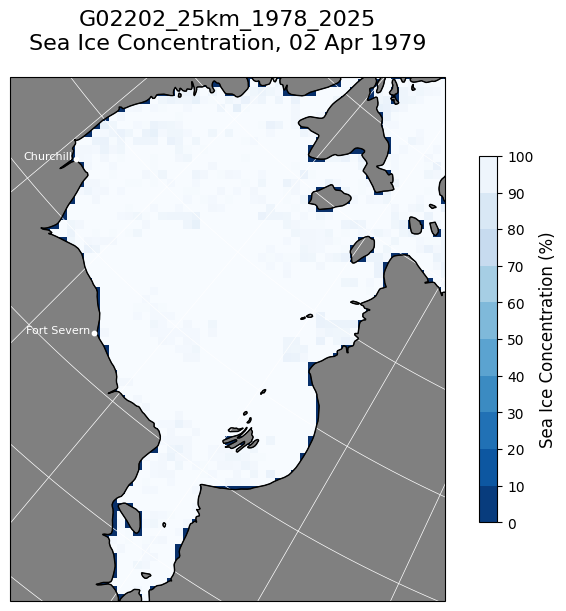

In [4]:
def plot_hudsonbay(ds_sel, name):
    # Define projection
    crs = ccrs.Stereographic(central_latitude=90, central_longitude=-45)

    # Use exact NSIDC polar stereographic
    crs_nsidc = ccrs.Stereographic(
        central_latitude=90,
        central_longitude=-45,
        true_scale_latitude=70,
        false_easting=0,
        false_northing=0
    )

    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True, subplot_kw={'projection': crs})

    # 1. Add ocean background
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')

    # 2. Plot sea ice
    if 'x' in ds_sel.coords:
        lat = ds.y
        lon = ds.x
        transform = crs_nsidc
    if 'lat' in ds_sel.coords:
        lat = ds.lat
        lon = ds.lon
        transform = ccrs.PlateCarree()

    im = ax.pcolormesh(
        lon, lat, ds_sel.values * 100,
        cmap='Blues_r',
        transform=transform,
        zorder=1
    )

    # 3. Add land on top of sea ice
    ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=2, facecolor='gray', edgecolor='black', linewidth=0.5)

    # 4. Add coastlines for clarity
    ax.coastlines(resolution='50m', zorder=3)

    # Approximate extent around Hudson Bay in degrees
    hudson_latlon_extent = [-85, -80, 51, 66]
    ax.set_extent(hudson_latlon_extent, crs=ccrs.PlateCarree())

    # Gridlines
    ax.gridlines(draw_labels=False, linewidth=0.5, color='white')

    # Colorbar
    cbar = plt.colorbar(im, orientation='vertical', boundaries=np.arange(0, 105, 10), ticks=np.linspace(0, 100, 11), pad=0.05, shrink=0.7)
    cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

    # Title
    date_str = ds_sel["time"].dt.strftime("%d %b %Y").item()
    ax.set_title(f'{name}\nSea Ice Concentration, {date_str}', fontsize=16, pad=20)

    # ============================================================
    # Load and set CRS
    pop_places = gpd.read_file('./populated-places-files/ne_10m_populated_places.shp')
    pop_places = pop_places.set_crs("EPSG:4326")

    # Define Hudson Bay extent in lon/lat
    lon_min, lon_max, lat_min, lat_max = -100, -70, 51, 60

    # Filter cities that fall within the extent
    pop_places_filtered = pop_places[
        (pop_places.geometry.x >= lon_min) &
        (pop_places.geometry.x <= lon_max) &
        (pop_places.geometry.y >= lat_min) &
        (pop_places.geometry.y <= lat_max)
    ]

    # Now reproject to NSIDC stereographic
    pop_places_proj = pop_places_filtered.to_crs(
        "+proj=stere +lat_0=90 +lat_ts=70 +lon_0=-45 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

    # Filter for major cities
    for _, row in pop_places_proj.iterrows():
        if row.get('SCALERANK', 10) < 4:

            # Plot city points
            ax.scatter(
                row.geometry.x,
                row.geometry.y,
                color='white',
                s=10,
                marker='o',
                transform=crs_nsidc,
                zorder=4,
            )

            # Plot city name
            ax.text(
                row.geometry.x-10000,
                row.geometry.y,
                row['NAME'],
                fontsize=8,
                color='white',
                transform=crs_nsidc,
                ha='right',
                zorder=5
                )
    # ============================================================

    plt.show()


for d, ds in enumerate(ds_all):
    ds_sel = ds.isel(time=159)
    # print(ds_sel.coords)
    plot_hudsonbay(ds_sel, names[d])

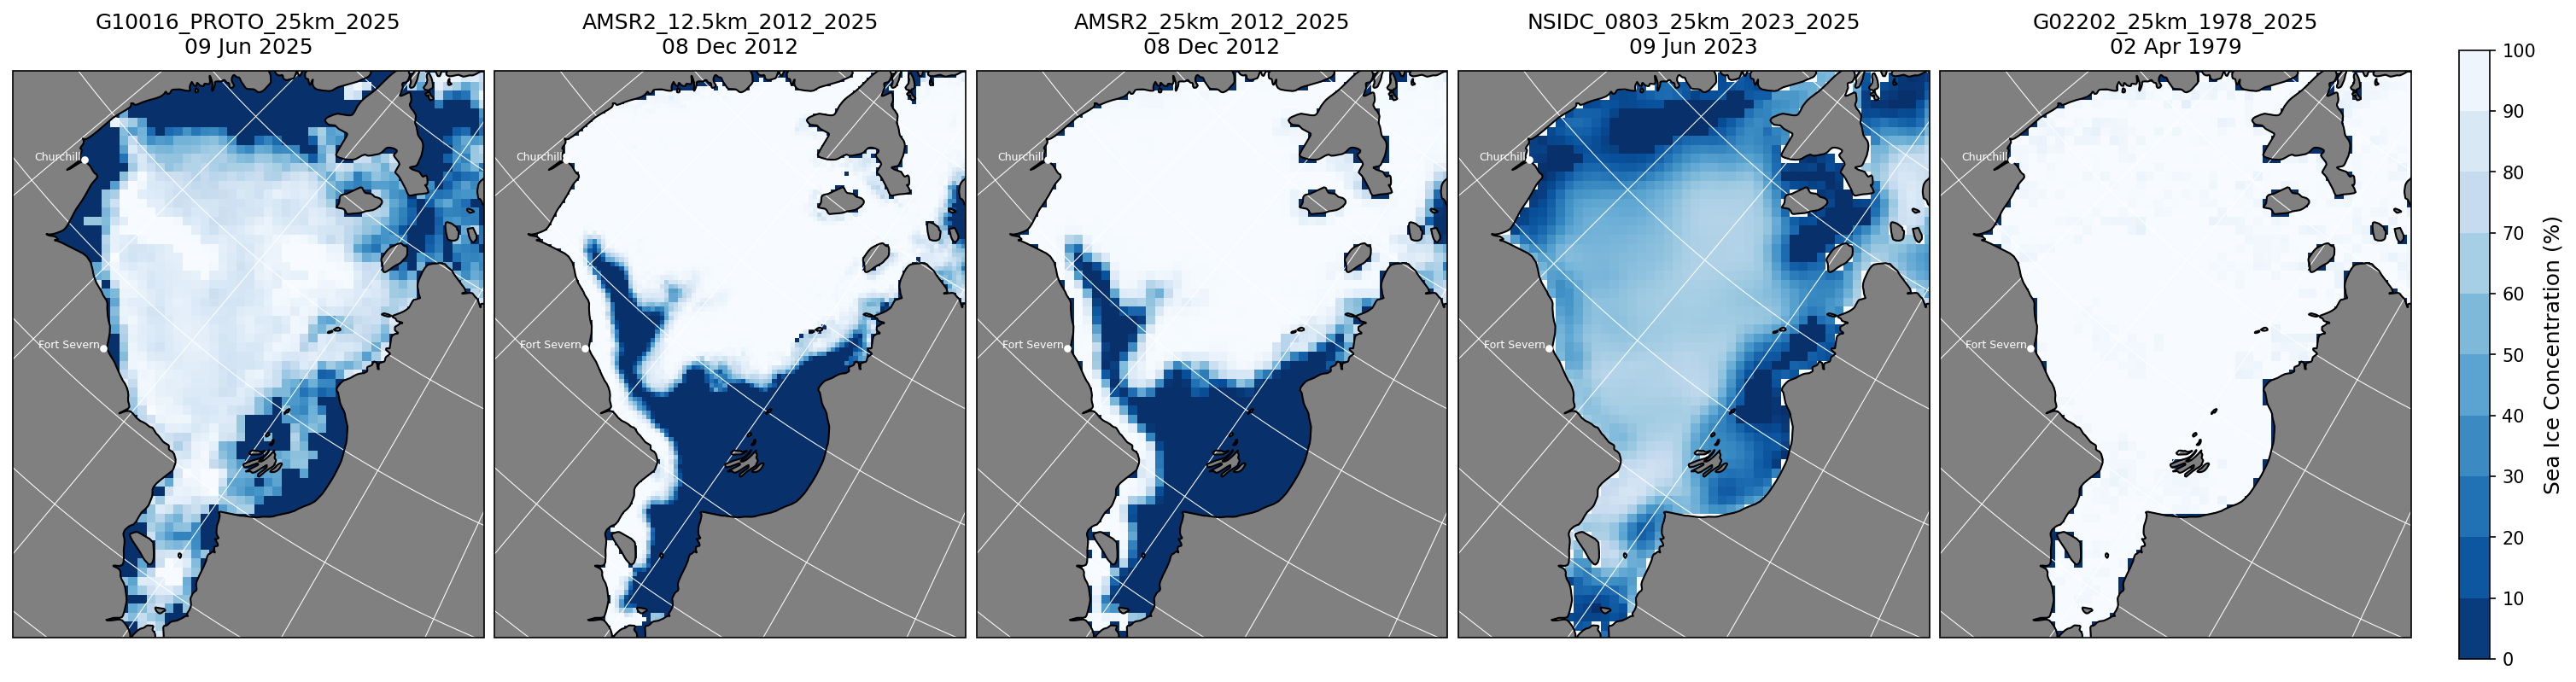

In [5]:
def plot_hudsonbay_all(ds_sel, name, ax, crs, crs_nsidc):
    # Add ocean background
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')

    # Plot sea ice
    if 'x' in ds_sel.coords:
        lat = ds_sel.y
        lon = ds_sel.x
        transform = crs_nsidc
    elif 'lat' in ds_sel.coords:
        lat = ds_sel.lat
        lon = ds_sel.lon
        transform = ccrs.PlateCarree()
    else:
        raise ValueError("No suitable lat/lon coordinates found")

    # min_val = np.nanmin(ds_sel)
    max_val = np.nanmax(ds_sel)
    if max_val <= 1.05:
        # print('Fraction:', names[d], min_val, max_val)
        ds_sel = ds_sel * 100
    # elif min_val >= 0 and max_val <= 100.0:
        # print('Percent:', names[d], min_val, max_val)
    # else:
        # print("Warning: SIC values outside expected range.", min_val, max_val)

    im = ax.pcolormesh(
        lon, lat, ds_sel.values,
        cmap='Blues_r',
        transform=transform,
        zorder=1
    )

    # Add land on top of sea ice
    ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=2, facecolor='gray', edgecolor='black', linewidth=0.5)

    # Add coastlines for clarity
    ax.coastlines(resolution='50m', zorder=3)

    # Approximate extent around Hudson Bay in degrees
    hudson_latlon_extent = [-85, -80, 51, 66]
    ax.set_extent(hudson_latlon_extent, crs=ccrs.PlateCarree())

    # Gridlines
    ax.gridlines(draw_labels=False, linewidth=0.5, color='white')

    # Title
    ax.set_title(f'{name}\n{ds_sel["time"].dt.strftime("%d %b %Y").item()}', fontsize=12, pad=10)

    # Load and set CRS for populated places
    pop_places = gpd.read_file('./populated-places-files/ne_10m_populated_places.shp')
    pop_places = pop_places.set_crs("EPSG:4326")

    # Define Hudson Bay extent in lon/lat
    lon_min, lon_max, lat_min, lat_max = -100, -70, 51, 60

    # Filter cities that fall within the extent
    pop_places_filtered = pop_places[
        (pop_places.geometry.x >= lon_min) &
        (pop_places.geometry.x <= lon_max) &
        (pop_places.geometry.y >= lat_min) &
        (pop_places.geometry.y <= lat_max)
    ]

    # Reproject to NSIDC stereographic
    pop_places_proj = pop_places_filtered.to_crs(crs_nsidc)

    # Filter for major cities and plot them
    for _, row in pop_places_proj.iterrows():
        if row.get('SCALERANK', 10) < 4:
            ax.scatter(
                row.geometry.x,
                row.geometry.y,
                color='white',
                s=10,
                marker='o',
                transform=crs_nsidc,
                zorder=4,
            )
            ax.text(
                row.geometry.x - 10000,
                row.geometry.y,
                row['NAME'],
                fontsize=6,
                color='white',
                transform=crs_nsidc,
                ha='right',
                zorder=5
            )
    return im


# Create figure and axes with projection
crs = ccrs.Stereographic(
    central_latitude=90,
    central_longitude=-45
)

crs_nsidc = ccrs.Stereographic(
    central_latitude=90,
    central_longitude=-45,
    true_scale_latitude=70,
    false_easting=0,
    false_northing=0
)

fig, axs = plt.subplots(1, 5, figsize=(20, 5), dpi=150, subplot_kw={'projection': crs}, constrained_layout=True)

ims = []

for d, ax in enumerate(axs):
    ds_sel = ds_all[d].isel(time=159)
    im = plot_hudsonbay_all(ds_sel, names[d], ax, crs, crs_nsidc)
    ims.append(im)

# Colorbar for all subplots (using the last image for scale)
levels = np.linspace(0, 100, 11)
cbar = fig.colorbar(ims[-1], ax=axs, orientation='vertical', boundaries=levels, ticks=levels, fraction=0.85, pad=0.02)
cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

plt.show()

In [6]:
for i, ds in enumerate(ds_all):
    print(names[i])
    print(ds.coords['time'].values[0])
    print(ds.coords['time'].values[-1])
    print('\n')

G10016_PROTO_25km_2025
2025-01-01T00:00:00.000000000
2025-08-30T00:00:00.000000000


AMSR2_12.5km_2012_2025
2012-07-02T00:00:00.000000000
2025-04-26T00:00:00.000000000


AMSR2_25km_2012_2025
2012-07-02T00:00:00.000000000
2025-08-31T00:00:00.000000000


NSIDC_0803_25km_2023_2025
2023-01-01T00:00:00.000000000
2025-09-08T00:00:00.000000000


G02202_25km_1978_2025
1978-10-25T00:00:00.000000000
2025-09-08T00:00:00.000000000


